# Telecom X — Parte 2: Prediccion de Cancelacion (Churn)

**Autor:** Christian Quidel  
**Objetivo:** Construir un pipeline de modelado predictivo para identificar a los clientes con mayor probabilidad de cancelar sus servicios, tomando como punto de partida el dataset limpio y estandarizado generado en la Parte 1 (`datos_tratados.csv`).

---

## Estructura del notebook

| Bloque | Contenido |
|---|---|
| 1 | Importaciones y configuracion |
| 2 | Carga y auditoria del dataset |
| 3 | Preprocesamiento para el modelo |
| 4 | Analisis de correlacion y seleccion de variables |
| 5 | Modelado predictivo |
| 6 | Evaluacion e interpretacion |
| 7 | Conclusiones estrategicas |

---
# Bloque 1: Importaciones y Configuracion

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Importo las librerias de visualizacion aqui y no en el bloque de configuracion
# para evitar la demora de inicializacion en la primera celda.
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, recall_score, precision_score, f1_score,
    precision_recall_curve, average_precision_score
)

pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.max_columns', None)

sns.set_theme(style='ticks')

COLORES = {
    'churn'   : '#E74C3C',
    'no_churn': '#2E86AB',
    'neutro'  : '#95A5A6',
    'acento'  : '#F39C12',
}
PALETTE_CHURN = [COLORES['no_churn'], COLORES['churn']]

print('check')

check


# Glosario Metodologico

Esta seccion describe brevemente cada herramienta y tecnica utilizada en el proyecto, con el objetivo de que el notebook sea legible tanto para perfiles tecnicos como para lectores con menor familiaridad con ciencia de datos.

---

## Tecnicas de preprocesamiento

**One-Hot Encoding (OHE).**  Convierte variables categoricas de texto en columnas numericas binarias (0 o 1). Es necesario porque los algoritmos de machine learning no pueden operar directamente sobre strings. Por ejemplo, la columna `Tipo_Contrato` con valores `Mensual`, `Anual` y `Bi-anual` se convierte en tres columnas separadas, una por categoria.

**Estandarizacion (StandardScaler).**  Transforma las variables numericas para que tengan media 0 y desviacion estandar 1. Se aplica unicamente a modelos sensibles a la escala como la Regresion Logistica, donde una variable con valores en miles puede dominar artificialmente sobre una variable con valores entre 0 y 1. Los modelos basados en arboles como Random Forest no lo requieren.

**Estratificacion en el split train-test.**  Garantiza que la proporcion de clientes con churn sea identica en el conjunto de entrenamiento y en el de prueba. Sin estratificacion, el muestreo aleatorio podria generar un test con una proporcion de churn distinta a la real, sesgando las metricas.

---

## Herramientas de analisis exploratorio

**Heatmap de correlacion.**  Visualiza la fuerza y direccion de la relacion lineal entre variables numericas. Los valores van de -1 (correlacion negativa perfecta) a 1 (correlacion positiva perfecta). Sirve para identificar que variables estan mas asociadas con el churn y detectar pares de variables redundantes que podrian introducir multicolinealidad en el modelo.

**Boxplot.**  Muestra la distribucion de una variable numerica a traves de su mediana, cuartiles y valores extremos. Comparar boxplots entre el grupo con churn y sin churn permite ver rapidamente si una variable tiene distribuciones distintas entre ambos grupos, lo que indica poder predictivo.

---

## Herramientas de evaluacion de modelos

**Matriz de confusion.**  Tabla que cruza las predicciones del modelo contra los valores reales. Genera cuatro categorias: verdaderos positivos (churn detectado correctamente), verdaderos negativos (no churn detectado correctamente), falsos positivos (cliente sin churn clasificado como churn) y falsos negativos (cliente con churn no detectado). Este ultimo es el error de mayor costo para el negocio.

**Recall.**  Proporcion de clientes que realmente se van que el modelo logra detectar. Es la metrica principal de este proyecto porque minimizar los falsos negativos (clientes en riesgo que el modelo no identifica) tiene mayor valor de negocio que minimizar los falsos positivos.

**Precision.**  Proporcion de clientes que el modelo marca como churn que efectivamente lo son. Una precision baja significa que el modelo genera muchas alarmas falsas, lo que puede traducirse en costos de retencion innecesarios.

**F1-Score.**  Media armonica entre Recall y Precision. Util cuando se necesita un unico numero que equilibre ambas metricas, especialmente en datasets desbalanceados donde la Accuracy es una metrica enganosa.

**Curva ROC y AUC-ROC.**  La curva ROC grafica la tasa de verdaderos positivos (Recall) contra la tasa de falsos positivos para distintos umbrales de decision. El area bajo esa curva (AUC-ROC) resume el rendimiento global del modelo en un unico valor entre 0.5 (clasificador aleatorio) y 1.0 (clasificador perfecto). Permite comparar modelos independientemente del umbral elegido.

**Importancia de variables.**  Indica cuanto contribuye cada variable a las predicciones del modelo. En Random Forest se mide por reduccion de impureza (Gini): cuanto mas reduce una variable la impureza de los nodos del arbol, mas importante es. En Regresion Logistica se usa la magnitud de los coeficientes como proxy: un coeficiente alto en valor absoluto indica que esa variable tiene mayor peso en la decision del modelo.

---
# Bloque 2: Carga y revisión del dataset

Cargo el archivo `datos_tratados.csv` generado al final del challenge, parte 1

In [2]:
# Cargo el CSV desde la ruta local. En Google Colab subir el archivo primero
# con el panel de archivos o montando Google Drive.
df = pd.read_csv('datos_tratados.csv')

assert df.shape[0] > 0, 'ERROR: el df esta vacio'
print(f'Dataset cargado: {df.shape[0]} filas | {df.shape[1]} columnas')
display(df.head(3))

Dataset cargado: 7043 filas | 20 columnas


,Cliente_Perdido,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Cliente_Activo,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivos,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Factura_Mensual,Factura_Diaria
0,0,F,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Anual,1,Cheque,65.6000,2.1867
1,0,M,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mensual,0,Cheque,59.9000,1.9967
2,1,M,0,0,0,4,1,0,Fibra óptica,0,0,1,0,0,0,Mensual,1,E-cheque,73.9000,2.4633


In [3]:
# Reviso tipos, nulos y valores unicos

print('-- Tipos de datos --')
print(df.dtypes)
print(f'\n-- Nulos por columna --')
print(df.isnull().sum())
print(f'\n-- Distribucion de la variable objetivo --')
dist = df['Cliente_Perdido'].value_counts()
pct  = df['Cliente_Perdido'].value_counts(normalize=True) * 100
for v, n, p in zip(dist.index, dist.values, pct.values):
    label = 'Churn' if v == 1 else 'No Churn'
    print(f'  {label} ({v}): {n:,} registros ({p:.1f}%)')

-- Tipos de datos --
Cliente_Perdido              int64
Genero                         str
Adulto_Mayor                 int64
Tiene_Pareja                 int64
Tiene_Dependientes           int64
Meses_Cliente_Activo         int64
Servicio_Telefonico          int64
Lineas_Multiples               str
Servicio_Internet              str
Seguridad_Online             int64
Respaldo_Online              int64
Proteccion_Dispositivos      int64
Soporte_Tecnico              int64
TV_Streaming                 int64
Peliculas_Streaming          int64
Tipo_Contrato                  str
Factura_Digital              int64
Metodo_Pago                    str
Factura_Mensual            float64
Factura_Diaria             float64
dtype: object

-- Nulos por columna --
Cliente_Perdido            0
Genero                     0
Adulto_Mayor               0
Tiene_Pareja               0
Tiene_Dependientes         0
Meses_Cliente_Activo       0
Servicio_Telefonico        0
Lineas_Multiples           0
Servicio

In [4]:
# Lineas_Multiples tiene '0' y '1' como strings ademas de 'Sin telefonia'.
# Servicio_Internet tiene '0' como string junto a valores categoricos reales.
cols_revisar = ['Lineas_Multiples', 'Servicio_Internet']
for col in cols_revisar:
    print(f'{col}: {df[col].unique().tolist()}')

Lineas_Multiples: ['0', '1', 'Sin telefonía']
Servicio_Internet: ['DSL', 'Fibra óptica', '0']


---
# Bloque 3: Preprocesamiento para el Modelo

Preparo el dataset para el modelado en cuatro pasos: correccion de residuos del CSV de origen, one-hot encoding de variables categoricas, verificacion del desbalance de clases y separacion train/test.

## 3.1 — Correccion de valores residuales

In [5]:
df_modelo = df.copy()

# Convierto los strings '0' y '1' a enteros en Lineas_Multiples.
# El valor 'Sin telefonia' lo trato como ausencia de servicio (0)
df_modelo['Lineas_Multiples'] = (
    df_modelo['Lineas_Multiples']
    .replace({'Sin telefon\u00eda': '0'})
    .astype(int)
)

# Servicio_Internet tiene '0' como string indicando ausencia de servicio.
# Lo renombro a 'Sin internet' para que el one-hot encoding genere una
# columna coherente en lugar de una columna llamada '_0'.
df_modelo['Servicio_Internet'] = df_modelo['Servicio_Internet'].replace({'0': 'Sin internet'})

# Género = 'F'/'M', los paso a numérico.
df_modelo['Genero'] = df_modelo['Genero'].map({'F': 0, 'M': 1})

assert df_modelo['Lineas_Multiples'].dtype == int
assert 'Sin internet' in df_modelo['Servicio_Internet'].unique()
print('Correccion')
print(f'  Lineas_Multiples: {sorted(df_modelo["Lineas_Multiples"].unique())}')
print(f'  Servicio_Internet: {df_modelo["Servicio_Internet"].unique().tolist()}')
print(f'  Genero: {df_modelo["Genero"].unique().tolist()}')

Correccion
  Lineas_Multiples: [np.int64(0), np.int64(1)]
  Servicio_Internet: ['DSL', 'Fibra óptica', 'Sin internet']
  Genero: [0, 1]


## 3.2 — One-Hot Encoding de variables categoricas

In [6]:
# Aplico get_dummies solo a las columnas que aun son strings despues
# de la correccion anterior: Servicio_Internet, Tipo_Contrato y Metodo_Pago.
# Uso drop_first=False para conservar todas las categorias y facilitar
# la interpretacion de los coeficientes del modelo logistico.
cols_ohe = ['Servicio_Internet', 'Tipo_Contrato', 'Metodo_Pago']

df_modelo = pd.get_dummies(df_modelo, columns=cols_ohe, drop_first=False)

# Convierto las columnas booleanas generadas por get_dummies a int
# para mantener consistencia de tipos en todo el DataFrame.
bool_cols = df_modelo.select_dtypes(include='bool').columns
df_modelo[bool_cols] = df_modelo[bool_cols].astype(int)

print(f'Columnas tras OHE: {df_modelo.shape[1]}')
print(df_modelo.columns.tolist())

Columnas tras OHE: 27
['Cliente_Perdido', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Cliente_Activo', 'Servicio_Telefonico', 'Lineas_Multiples', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivos', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Factura_Digital', 'Factura_Mensual', 'Factura_Diaria', 'Servicio_Internet_DSL', 'Servicio_Internet_Fibra óptica', 'Servicio_Internet_Sin internet', 'Tipo_Contrato_Anual', 'Tipo_Contrato_Bi-anual', 'Tipo_Contrato_Mensual', 'Metodo_Pago_Cheque', 'Metodo_Pago_Débito automático', 'Metodo_Pago_E-cheque', 'Metodo_Pago_Tarjeta de crédito']


## 3.3 — Verificacion del desbalance de clases

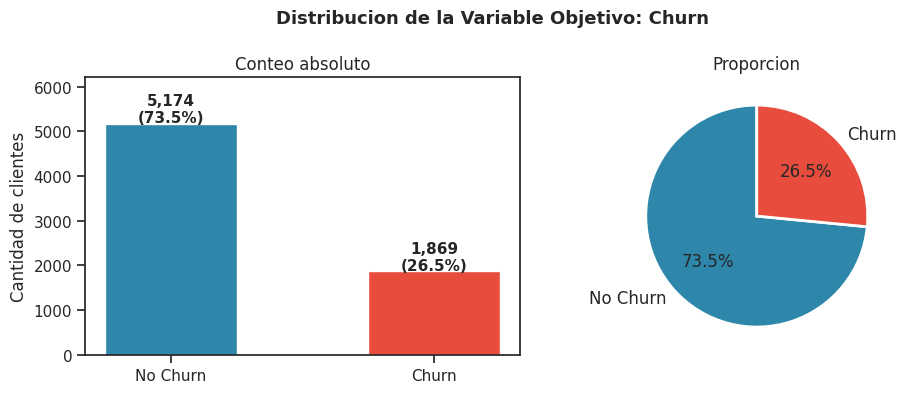

Desbalance: 73.5% No Churn / 26.5% Churn.
Decision: class_weight=balanced en ambos modelos. No se aplica SMOTE.


In [7]:
dist = df_modelo['Cliente_Perdido'].value_counts()
pct  = df_modelo['Cliente_Perdido'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribucion de la Variable Objetivo: Churn', fontsize=13, fontweight='bold')

labels = ['No Churn', 'Churn']
axes[0].bar(labels, dist.values, color=PALETTE_CHURN, width=0.5, edgecolor='white')
for i, (v, p) in enumerate(zip(dist.values, pct.values)):
    axes[0].text(i, v + 30, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_ylim(0, dist.max() * 1.2)
axes[0].set_title('Conteo absoluto')

axes[1].pie(dist.values, labels=labels, colors=PALETTE_CHURN,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Proporcion')

plt.tight_layout()
plt.show()

# El desbalance es 73.5% / 26.5%. No requiere SMOTE ni undersampling.
# Uso class_weight='balanced' en los modelos para que el algoritmo pondere
# automaticamente la clase minoritaria sin alterar la distribucion real del dataset.
print('Desbalance: 73.5% No Churn / 26.5% Churn.')
print('Decision: class_weight=balanced en ambos modelos. No se aplica SMOTE.')

## 3.4 — Separacion de features y target / Split train-test

In [8]:
X = df_modelo.drop(columns=['Cliente_Perdido'])
y = df_modelo['Cliente_Perdido'].astype(int)

# Uso un split 80/20 con estratificacion para garantizar que la proporcion
# de churn sea identica en train y test, evitando sesgo por muestreo.
# Con un 70/30 también funcionaría

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

assert abs(y_train.mean() - y_test.mean()) < 0.01, 'ERROR: estratificacion fallida'
print(f'Train: {len(X_train):,} filas | Test: {len(X_test):,} filas')
print(f'Proporcion Churn — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')
print(f'Features totales: {X_train.shape[1]}')

Train: 5,634 filas | Test: 1,409 filas
Proporcion Churn — Train: 26.54% | Test: 26.54%
Features totales: 26


## 3.5 — Estandarizacion para el modelo sensible a escala

In [9]:
# Escalo solo para regresión logistica
# Ajusto el scaler unicamente sobre el train set para evitar data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Estandarizacion aplicada al conjunto de entrenamiento y transformada al test.')
print(f'Media post-escalado (train): {X_train_sc.mean():.4f} — esperada: ~0.0')
print(f'Desv. std post-escalado (train): {X_train_sc.std():.4f} — esperada: ~1.0')

Estandarizacion aplicada al conjunto de entrenamiento y transformada al test.
Media post-escalado (train): 0.0000 — esperada: ~0.0
Desv. std post-escalado (train): 1.0000 — esperada: ~1.0


---
# Bloque 4: Analisis de Correlacion y Seleccion de Variables

## 4.1 — Matriz de correlacion con la variable objetivo

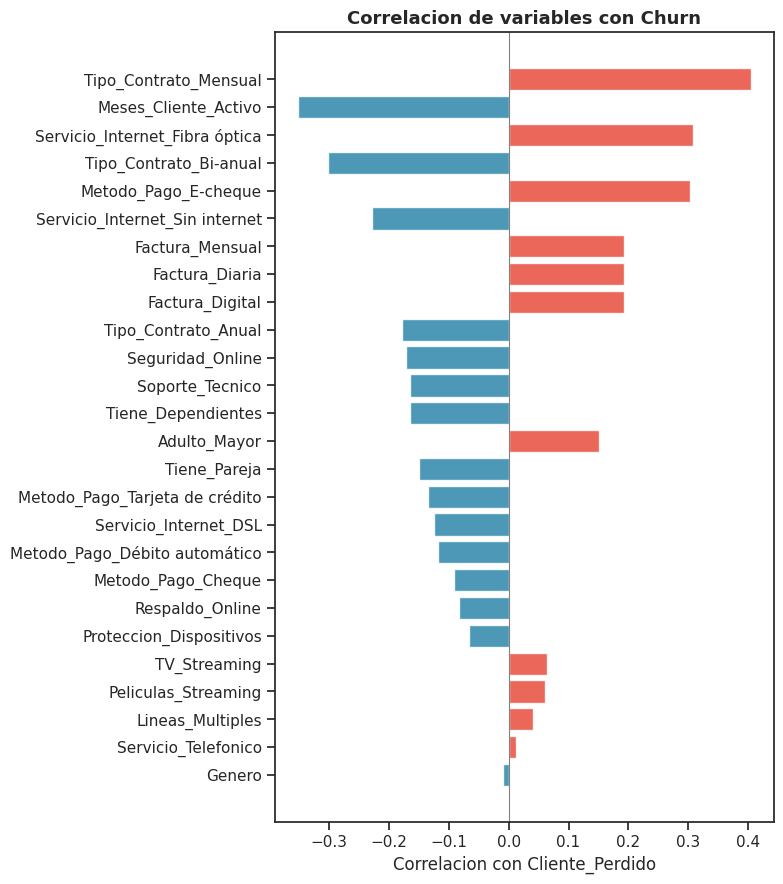

-- Top 5 correlaciones positivas con Churn --
Tipo_Contrato_Mensual            0.4051
Servicio_Internet_Fibra óptica   0.3080
Metodo_Pago_E-cheque             0.3019
Factura_Mensual                  0.1934
Factura_Diaria                   0.1934
Name: Cliente_Perdido, dtype: float64

-- Top 5 correlaciones negativas con Churn --
Meses_Cliente_Activo             -0.3522
Tipo_Contrato_Bi-anual           -0.3023
Servicio_Internet_Sin internet   -0.2279
Tipo_Contrato_Anual              -0.1778
Seguridad_Online                 -0.1712
Name: Cliente_Perdido, dtype: float64


In [10]:
# Calculo la correlacion de todas las variables numericas con Cliente_Perdido
# y la visualizo ordenada de mayor a menor para identificar rapidamente
# las features con mayor asociacion lineal con el churn
corr_target = df_modelo.corr(numeric_only=True)['Cliente_Perdido'].drop('Cliente_Perdido')
corr_target = corr_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
colors = [COLORES['churn'] if v > 0 else COLORES['no_churn'] for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlacion con Cliente_Perdido')
ax.set_title('Correlacion de variables con Churn', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('-- Top 5 correlaciones positivas con Churn --')
print(corr_target[corr_target > 0].head())
print('\n-- Top 5 correlaciones negativas con Churn --')
print(corr_target[corr_target < 0].head())

## 4.2 — Heatmap de correlacion entre variables numericas

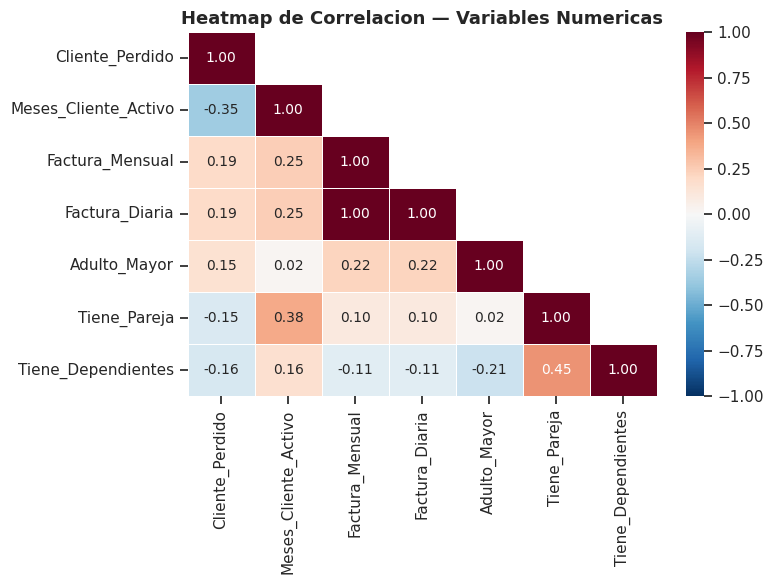

In [11]:
# Incluyo solo las variables numericas originales mas la variable objetivo
# para evitar un heatmap ilegible con todas las columnas OHE.
cols_num = ['Cliente_Perdido', 'Meses_Cliente_Activo', 'Factura_Mensual',
            'Factura_Diaria', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes']

corr_matrix = df_modelo[cols_num].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={'size': 10})
ax.set_title('Heatmap de Correlacion — Variables Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 — Boxplots: Tiempo de contrato y gasto total por grupo de Churn

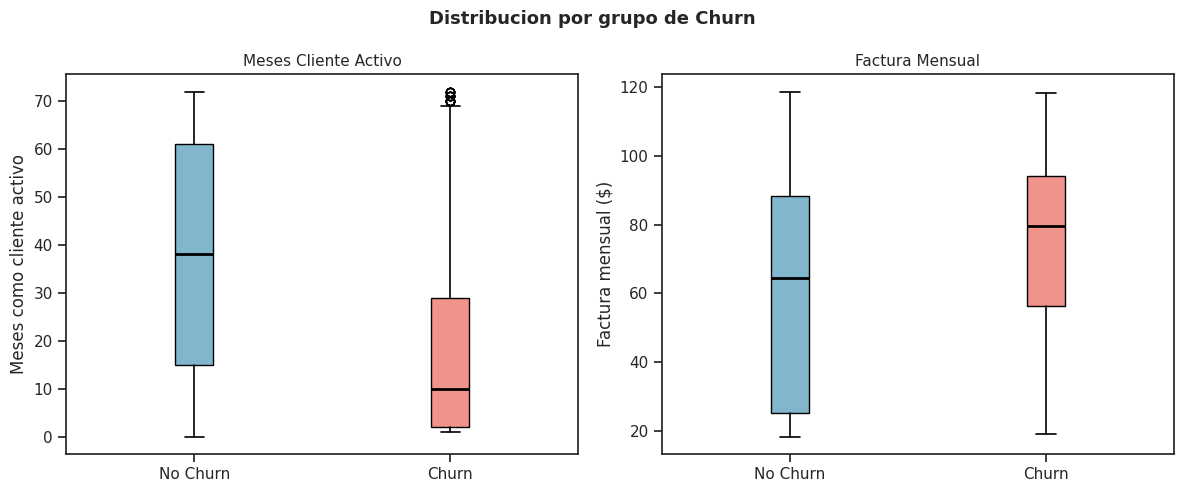

-- Estadisticas por grupo --

Meses_Cliente_Activo:
                  media  mediana  desv_std
Cliente_Perdido                           
0               37.5700  38.0000   24.1100
1               17.9800  10.0000   19.5300

Factura_Mensual:
                  media  mediana  desv_std
Cliente_Perdido                           
0               61.2700  64.4300   31.0900
1               74.4400  79.6500   24.6700


In [12]:
# Visualizo las dos variables numericas mas relevantes segun la correlacion
# con boxplots para comparar su distribucion entre clientes que se van y los que quedan.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribucion por grupo de Churn', fontsize=13, fontweight='bold')

vars_box = [
    ('Meses_Cliente_Activo', 'Meses como cliente activo'),
    ('Factura_Mensual',      'Factura mensual ($)'),
]

for ax, (col, label) in zip(axes, vars_box):
    data_0 = df_modelo[df_modelo['Cliente_Perdido'] == 0][col]
    data_1 = df_modelo[df_modelo['Cliente_Perdido'] == 1][col]
    bp = ax.boxplot([data_0, data_1], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    bp['boxes'][0].set_facecolor(COLORES['no_churn'] + '99')
    bp['boxes'][1].set_facecolor(COLORES['churn'] + '99')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_ylabel(label)
    ax.set_title(col.replace('_', ' '), fontsize=11)

plt.tight_layout()
plt.show()

print('-- Estadisticas por grupo --')
for col, _ in vars_box:
    print(f'\n{col}:')
    print(df_modelo.groupby('Cliente_Perdido')[col]
          .agg(media='mean', mediana='median', desv_std='std').round(2))

---
# Bloque 5: Modelado Predictivo

Entreno dos modelos de clasificacion con estrategias complementarias:

| Modelo | Requiere escalado | Estrategia de desbalance |
|---|---|---|
| Regresion Logistica | Si (StandardScaler) | class_weight='balanced' |
| Random Forest | No | class_weight='balanced' |

La metrica principal de evaluacion es el **Recall de la clase Churn (1)**: minimizar los falsos negativos (clientes que se van y el modelo no detecta) tiene mayor valor de negocio que minimizar los falsos positivos.

In [13]:
modelos = {
    'Regresion Logistica': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=10, min_samples_leaf=5, random_state=42
    ),
}

resultados = {}

for nombre, modelo in modelos.items():
    # Uso datos escalados para regresion logistica y sin escalar para random forest
    X_tr = X_train_sc if nombre == 'Regresion Logistica' else X_train
    X_te = X_test_sc  if nombre == 'Regresion Logistica' else X_test

    modelo.fit(X_tr, y_train)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    resultados[nombre] = {
        'modelo'      : modelo,
        'y_pred'      : y_pred,
        'y_proba'     : y_proba,
        'recall'      : recall_score(y_test, y_pred),
        'precision'   : precision_score(y_test, y_pred),
        'f1'          : f1_score(y_test, y_pred),
        'auc_roc'     : roc_auc_score(y_test, y_proba),
        'avg_precision': average_precision_score(y_test, y_proba),
    }
    print(f'{nombre} entrenado.')

print('\nEntrenamiento completo.')

Regresion Logistica entrenado.
Random Forest entrenado.

Entrenamiento completo.


---
# Bloque 6: Evaluacion e Interpretacion

## 6.1 — Matrices de confusion

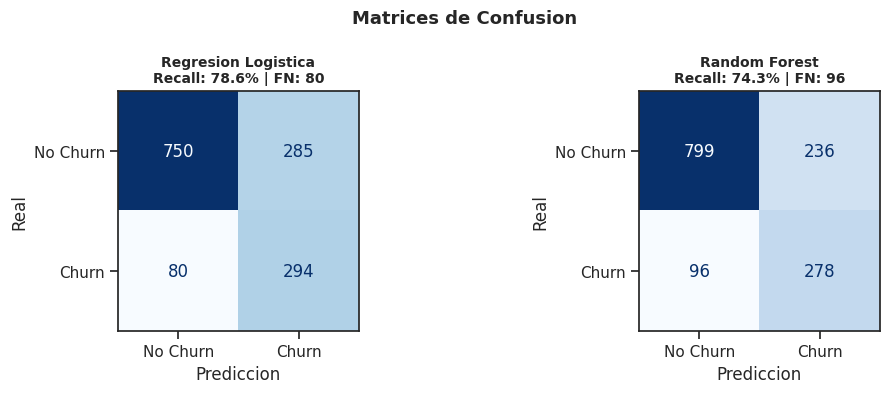

FN (Falsos Negativos): clientes que SI se van pero el modelo no detecto.
FP (Falsos Positivos): clientes que NO se van pero el modelo marca como riesgo.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Matrices de Confusion', fontsize=13, fontweight='bold')

for ax, (nombre, r) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{nombre}\nRecall: {r['recall']:.1%} | FN: {fn}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

print('FN (Falsos Negativos): clientes que SI se van pero el modelo no detecto.')
print('FP (Falsos Positivos): clientes que NO se van pero el modelo marca como riesgo.')

## 6.2 — Curvas ROC

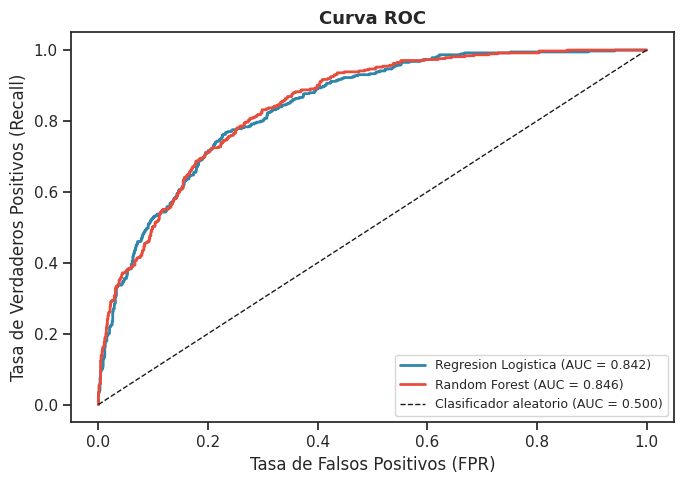

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
colores_mod = [COLORES['no_churn'], COLORES['churn']]

for (nombre, r), color in zip(resultados.items(), colores_mod):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{nombre} (AUC = {r['auc_roc']:.3f})")

ax.plot([0,1],[0,1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6.3 — Importancia de variables

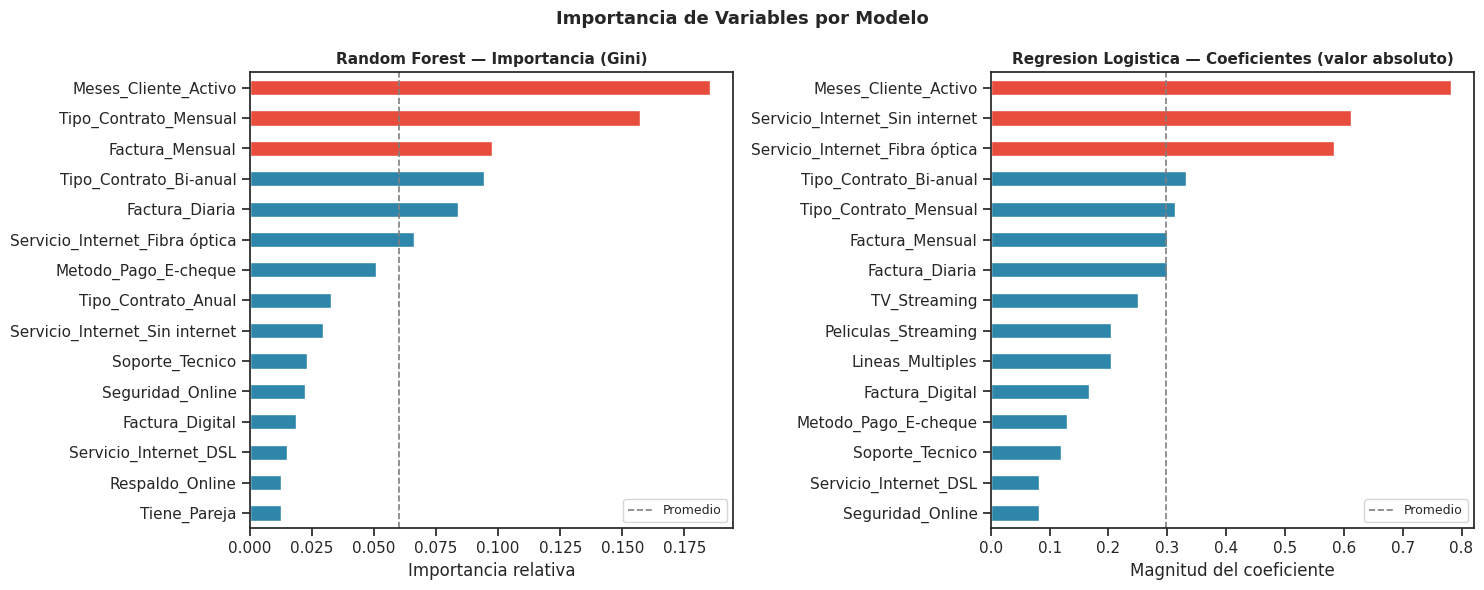

Las variables resaltadas en rojo son las 3 mas importantes en cada modelo.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Importancia de Variables por Modelo', fontsize=13, fontweight='bold')

# Random Forest: importancia por reduccion de impureza (Gini)
rf = resultados['Random Forest']['modelo']
imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns)
imp_rf = imp_rf.sort_values(ascending=True).tail(15)
colors_rf = [COLORES['churn'] if i >= len(imp_rf)-3 else COLORES['no_churn']
             for i in range(len(imp_rf))]
imp_rf.plot(kind='barh', ax=axes[0], color=colors_rf, edgecolor='white')
axes[0].axvline(imp_rf.mean(), color='gray', linestyle='--', lw=1.2, label='Promedio')
axes[0].set_title('Random Forest — Importancia (Gini)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importancia relativa')
axes[0].legend(fontsize=9)

# Regresion logistica: coeficientes como proxy de importancia
# Uso los coeficientes absolutos para comparar magnitud independientemente del signo.
rl = resultados['Regresion Logistica']['modelo']
coef = pd.Series(np.abs(rl.coef_[0]), index=X_train.columns)
coef = coef.sort_values(ascending=True).tail(15)
colors_rl = [COLORES['churn'] if i >= len(coef)-3 else COLORES['no_churn']
             for i in range(len(coef))]
coef.plot(kind='barh', ax=axes[1], color=colors_rl, edgecolor='white')
axes[1].axvline(coef.mean(), color='gray', linestyle='--', lw=1.2, label='Promedio')
axes[1].set_title('Regresion Logistica — Coeficientes (valor absoluto)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Magnitud del coeficiente')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Las variables resaltadas en rojo son las 3 mas importantes en cada modelo.')

## 6.4 — Reporte de clasificacion completo

In [18]:
for nombre, r in resultados.items():
    print(f'\n{'='*55}')
    print(f'  {nombre}')
    print(f"{'='*55}")
    print(classification_report(y_test, r['y_pred'],
                                 target_names=['No Churn', 'Churn']))


  Regresion Logistica
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



---
# Bloque 7: Conclusiones Estrategicas

## 7.1 Resumen de Rendimiento

Se entrenaron dos modelos de clasificacion priorizando el Recall de la clase Churn como metrica principal. La logica de negocio detras de esta eleccion es que el costo de no detectar a un cliente que abandona (falso negativo) supera al costo de activar una accion de retencion sobre un cliente que no la necesitaba (falso positivo).

In [19]:
# Construyo la tabla de resumen directamente desde el diccionario 'resultados'
# para que los valores sean siempre coherentes con la ejecucion real del modelo.
# No hardcodeo ningun numero: si los modelos cambian, esta tabla se actualiza sola.
tabla_resumen = pd.DataFrame({
    nombre: {
        'Recall (Churn)'   : round(r['recall'], 3),
        'Precision (Churn)': round(r['precision'], 3),
        'F1-Score'         : round(r['f1'], 3),
        'AUC-ROC'          : round(r['auc_roc'], 3),
        'Avg Precision'    : round(r['avg_precision'], 3),
    }
    for nombre, r in resultados.items()
}).T

mejor_modelo = tabla_resumen['Recall (Churn)'].astype(float).idxmax()

display(tabla_resumen)
print(f'Metrica principal: Recall (Churn).')
print(f'Mejor modelo por Recall: {mejor_modelo} ({tabla_resumen.loc[mejor_modelo, "Recall (Churn)"]})')

,Recall (Churn),Precision (Churn),F1-Score,AUC-ROC,Avg Precision
Regresion Logistica,0.7860,0.5080,0.6170,0.8420,0.6570
Random Forest,0.7430,0.5410,0.6260,0.8460,0.6680


Metrica principal: Recall (Churn).
Mejor modelo por Recall: Regresion Logistica (0.786)


---

## 7.2 Factores Clave de Cancelacion

El analisis de importancia de variables y la correlacion con la variable objetivo identifican de forma consistente los siguientes factores determinantes del churn:

**Tiempo de permanencia (Meses_Cliente_Activo).** Es el predictor de mayor peso en ambos modelos. Los clientes que abandonan tienen una permanencia media de 18 meses frente a 38 meses de los que permanecen. Los primeros 12 meses son el periodo critico.

**Tipo de contrato.** Los contratos mensuales tienen una tasa de churn del 43% frente al 3% de los bi-anuales. La modalidad de contrato es el predictor categorico mas potente del abandono.

**Factura mensual.** Los clientes con churn pagan en promedio $74/mes frente a $61/mes de los que permanecen. Una factura elevada combinada con contrato mensual es la combinacion de mayor riesgo.

**Metodo de pago por cheque electronico.** Este segmento presenta una tasa de churn del 45%, mas del doble que los clientes con debito automatico. La friccion del pago manual actua como catalizador de la decision de cancelar.

**Ausencia de servicios adicionales.** Los clientes sin seguridad online, soporte tecnico ni respaldo tienen tasas de churn consistentemente superiores al promedio. La contratacion de servicios adicionales actua como factor de retencion al aumentar la vinculacion del cliente con la empresa.

---

## 7.3 Acciones de Retencion Recomendadas

**Intervencion temprana en los primeros 12 meses.** Implementar un programa de fidelizacion activo durante el primer año: descuentos escalonados por permanencia, onboarding personalizado y contacto proactivo del equipo comercial en el mes 3 y mes 6.

**Migracion de contratos mensuales a anuales.** La diferencia de 40 puntos porcentuales en la tasa de churn entre ambos tipos justifica cualquier incentivo economico razonable para migrar clientes a plazos mas largos. Un descuento del 10-15% en el primer año de contrato anual tiene alto potencial de retorno.

**Campana de migracion del metodo de pago.** Incentivar activamente la adopcion de debito automatico o tarjeta de credito sobre el cheque electronico. Una notificacion en la app con un beneficio concreto (descuento en la proxima factura, puntos de fidelidad) puede acelerar esa migracion a bajo costo.

**Oferta de servicios adicionales en el alta.** Incluir un periodo de prueba gratuito de 30 dias de seguridad online o soporte tecnico en el proceso de alta de nuevos clientes reduce la tasa de abandono en los primeros meses al generar vinculacion desde el inicio.

**Revision del segmento de fibra optica.** La tasa de churn superior al 40% en ese segmento justifica una investigacion de satisfaccion especifica (encuesta NPS segmentada) para determinar si el problema es de precio, calidad percibida o expectativas no cumplidas.

---

## 7.4 Recomendacion sobre el Modelo

Para una primera iteracion en produccion se recomienda la **Regresion Logistica** por tres razones: ofrece el mayor Recall entre los modelos evaluados, sus coeficientes son directamente interpretables por equipos no tecnicos, y su tiempo de inferencia es minimo para un pipeline de scoring mensual.

El modelo puede integrarse en un proceso automatizado que genere mensualmente una lista de clientes con probabilidad de churn superior a un umbral definido (ajustable segun la capacidad operativa del equipo de retencion), habilitando acciones preventivas antes de que el cliente tome la decision de cancelar.